<a href="https://colab.research.google.com/github/pavithran-r84/Marketing-Spend-and-Product-Sales-Analysis/blob/main/regression_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded

       TV  Billboards  Google_Ads  Social_Media  Influencer_Marketing  \
0  281.42      538.80      123.94        349.30                242.77   
1  702.97      296.53      558.13        180.55                781.06   
2  313.14      295.94      642.96        505.71                438.91   
3  898.52       61.27      548.73        240.93                278.96   
4  766.52      550.72      651.91        666.33                396.33   

   Affiliate_Marketing  Product_Sold  total_spend  cost_per_scold  \
0               910.10          7164      2446.33        0.341475   
1               132.43          5055      2651.67        0.524564   
2               464.23          6154      2660.89        0.432384   
3               432.27          5480      2460.68        0.449029   
4               841.93          9669      3873.74        0.400635   

   traditional_category  digital_category  partnership_category  \
0                820.22            473.24                242.77

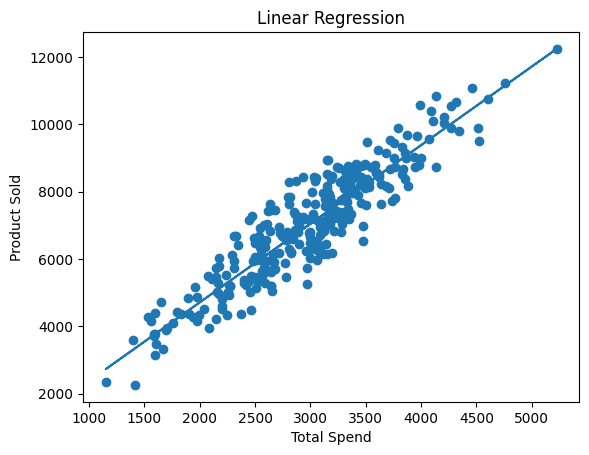


===== Polynomial Regression =====
Train R²: 0.8510207647725374
Test R² : 0.8246910628844846
Full R² : 0.8468594090767954


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


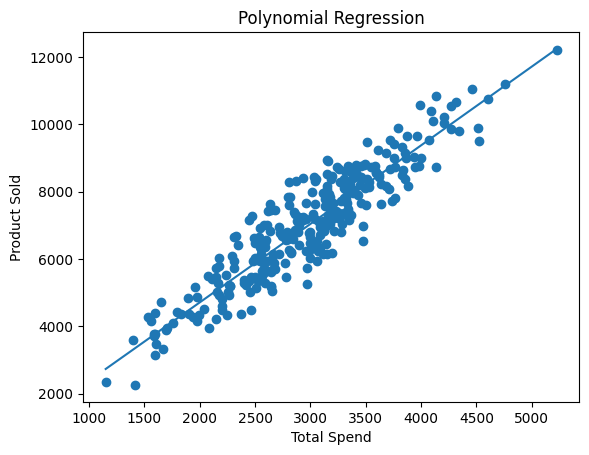


===== Multiple Regression (Channel) =====
Train R²: 0.9999606679323896
Test R² : 0.9999736866138691
Full R² : 0.9999635239900844

Channel Impact:
                 Channel  Coefficient
5   Affiliate_Marketing     3.996625
1            Billboards     2.998532
3          Social_Media     2.499797
0                    TV     2.001823
2            Google_Ads     1.498071
4  Influencer_Marketing     1.199659


Exception ignored in: <function ZipFile.__del__ at 0x7a1ed4f8bec0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1966, in __del__
    self.close()
  File "/usr/lib/python3.12/zipfile/__init__.py", line 1983, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


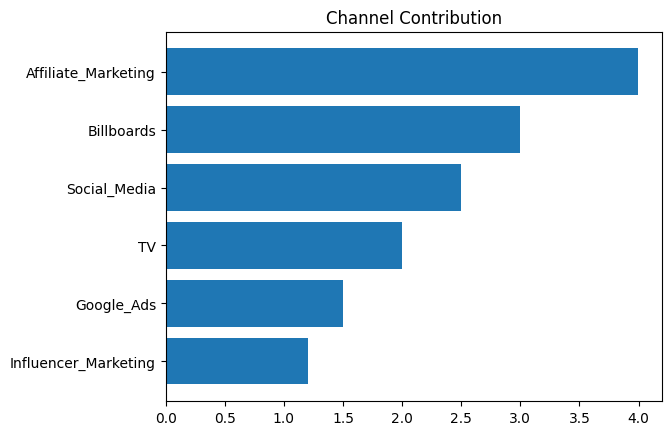


===== Category Regression =====
Train R²: 0.9712928461317044
Test R² : 0.9749168577123535
Full R² : 0.9722133768851712

Category Impact:
                Category  Coefficient
3    affiliate_category     3.985686
0  traditional_category     2.464716
1      digital_category     2.010889
2  partnership_category     1.254126


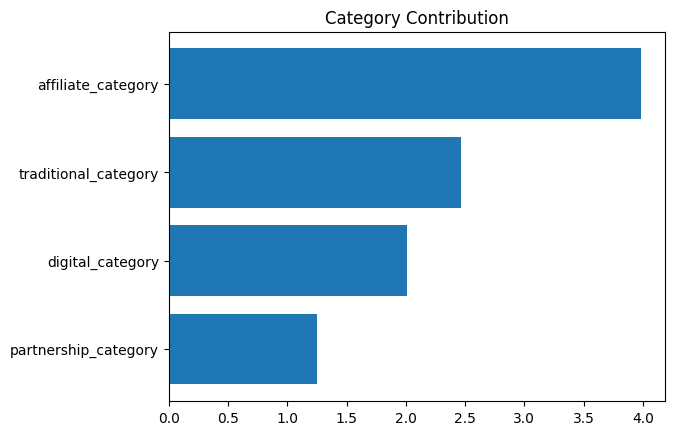


===== MODEL COMPARISON =====

                               Train_R2   Test_R2   Full_R2
Linear Regression              0.851020  0.824844  0.846889
Polynomial Regression          0.851021  0.824691  0.846859
Multiple Regression (Channel)  0.999961  0.999974  0.999964
Category Regression            0.971293  0.974917  0.972213

Best Model: Multiple Regression (Channel)


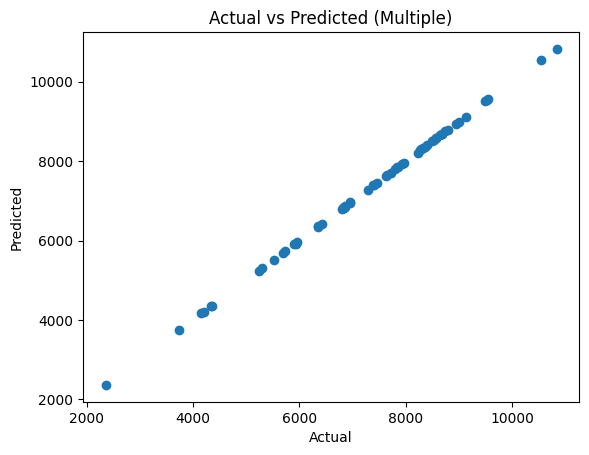

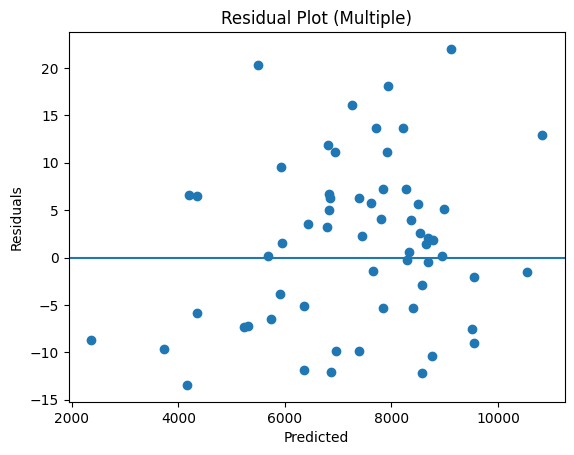


Residual Sample:
 203   -6.514749
266   -2.950438
152    7.211170
9      1.384216
233   -0.302510
Name: Product_Sold, dtype: float64
✅ model_outputs.xlsx created!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score


def run_full_pipeline(file_path, sheet_name):


    # 1. LOAD DATA

    df = pd.read_excel(file_path, sheet_name=sheet_name)
    print("Dataset Loaded\n")
    print(df.head())


    # 2. FEATURE ENGINEERING

    channels = ['TV', 'Billboards', 'Google_Ads',
                'Social_Media', 'Influencer_Marketing',
                'Affiliate_Marketing']

    df['total_spend'] = df[channels].sum(axis=1)

    # Categories
    df['traditional_category'] = df['TV'] + df['Billboards']
    df['digital_category'] = df['Google_Ads'] + df['Social_Media']
    df['partnership_category'] = df['Influencer_Marketing']
    df['affiliate_category'] = df['Affiliate_Marketing']

    y = df['Product_Sold']


    # 3. SPLIT

    X_simple = df[['total_spend']]
    X_multi = df[channels]
    X_cat = df[['traditional_category', 'digital_category',
                'partnership_category', 'affiliate_category']]

    X_train_s, X_test_s, y_train, y_test = train_test_split(
        X_simple, y, test_size=0.2, random_state=42
    )

    X_train_m = X_multi.loc[X_train_s.index]
    X_test_m = X_multi.loc[X_test_s.index]

    X_train_c = X_cat.loc[X_train_s.index]
    X_test_c = X_cat.loc[X_test_s.index]

    results = {}


    # FUNCTION: EVALUATE

    def evaluate(name, model, X_train, X_test, X_full):
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        y_full_pred = model.predict(X_full)

        r2_train = r2_score(y_train, y_train_pred)
        r2_test = r2_score(y_test, y_test_pred)
        r2_full = r2_score(y, y_full_pred)

        results[name] = {
            "Train_R2": r2_train,
            "Test_R2": r2_test,
            "Full_R2": r2_full
        }

        print(f"\n===== {name} =====")
        print("Train R²:", r2_train)
        print("Test R² :", r2_test)
        print("Full R² :", r2_full)

        return model, y_test_pred


    # 4. LINEAR REGRESSION

    model_linear, y_pred_linear = evaluate(
        "Linear Regression",
        LinearRegression(),
        X_train_s, X_test_s, X_simple
    )

    plt.figure()
    plt.scatter(X_simple, y)
    plt.plot(X_simple, model_linear.predict(X_simple))
    plt.title("Linear Regression")
    plt.xlabel("Total Spend")
    plt.ylabel("Product Sold")
    plt.show()


    # 5. POLYNOMIAL REGRESSION

    poly = PolynomialFeatures(degree=2)

    X_poly = poly.fit_transform(X_simple)
    X_train_p = poly.transform(X_train_s)
    X_test_p = poly.transform(X_test_s)

    model_poly, y_pred_poly = evaluate(
        "Polynomial Regression",
        LinearRegression(),
        X_train_p, X_test_p, X_poly
    )

    X_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)

    plt.figure()
    plt.scatter(X_simple, y)
    plt.plot(X_range, model_poly.predict(X_range_poly))
    plt.title("Polynomial Regression")
    plt.xlabel("Total Spend")
    plt.ylabel("Product Sold")
    plt.show()


    # 6. MULTIPLE REGRESSION (CHANNEL)

    model_multi, y_pred_multi = evaluate(
        "Multiple Regression (Channel)",
        LinearRegression(),
        X_train_m, X_test_m, X_multi
    )

    coeff_df = pd.DataFrame({
        'Channel': channels,
        'Coefficient': model_multi.coef_
    }).sort_values(by='Coefficient', ascending=False)

    print("\nChannel Impact:\n", coeff_df)

    plt.figure()
    plt.barh(coeff_df['Channel'], coeff_df['Coefficient'])
    plt.gca().invert_yaxis()
    plt.title("Channel Contribution")
    plt.show()


    # 7. CATEGORY REGRESSION

    model_cat, y_pred_cat = evaluate(
        "Category Regression",
        LinearRegression(),
        X_train_c, X_test_c, X_cat
    )

    coeff_cat_df = pd.DataFrame({
        'Category': X_cat.columns,
        'Coefficient': model_cat.coef_
    }).sort_values(by='Coefficient', ascending=False)

    print("\nCategory Impact:\n", coeff_cat_df)

    plt.figure()
    plt.barh(coeff_cat_df['Category'], coeff_cat_df['Coefficient'])
    plt.gca().invert_yaxis()
    plt.title("Category Contribution")
    plt.show()

    # 8. BEST MODEL

    results_df = pd.DataFrame(results).T
    best_model = results_df['Test_R2'].idxmax()

    print("\n===== MODEL COMPARISON =====\n")
    print(results_df)
    print(f"\nBest Model: {best_model}")


    # 9. ACTUAL vs PREDICTED (MULTIPLE)
  +
    plt.figure()
    plt.scatter(y_test, y_pred_multi)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted (Multiple)")
    plt.show()


    # 10. RESIDUAL PLOT

    residuals = y_test - y_pred_multi

    plt.figure()
    plt.scatter(y_pred_multi, residuals)
    plt.axhline(y=0)
    plt.xlabel("Predicted")
    plt.ylabel("Residuals")
    plt.title("Residual Plot (Multiple)")
    plt.show()

    print("\nResidual Sample:\n", residuals.head())

    return coeff_df, coeff_cat_df, y_test, y_pred_multi

# RUN PIPELINE

coeff_df, coeff_cat_df, y_test, y_pred_multi = run_full_pipeline(
    "/content/working_data.xlsx", "cleaned_datas"
)

#for extracting the output of it

with pd.ExcelWriter("model_outputs.xlsx") as writer:
    coeff_df.to_excel(writer, sheet_name="Channel Impact", index=False)
    coeff_cat_df.to_excel(writer, sheet_name="Category Impact", index=False)

    pred_df = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred_multi
    })

    pred_df.to_excel(writer, sheet_name="Predictions", index=False)

print("✅ model_outputs.xlsx created!")